# Cell in BrainCell

This notebook is the direct sequel to `1.morphology.ipynb`.

In the previous tutorial, we focused on geometry and topology. Here we move one layer upward and ask a new question:

**How does a morphology become a simulation-ready cell object?**

We will focus on four ideas:

1. Build a `Cell` directly from an existing morphology.
2. Inspect control volumes (`CV`s), which are the basic structural units of the cell layer.
3. Compare different `cv_policy` choices.
4. Use the declarative APIs `paint(...)` and `place(...)`.

To keep this notebook focused on the cell layer, we will load a ready-made morphology from `./morpho_files/example_tree.swc` instead of rebuilding one by hand.

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import brainstate
import brainunit as u
import matplotlib.pyplot as plt

from braincell import Cell, Morphology
from braincell import CVPerBranch, MaxCVLen
from braincell.filter import BranchSlice, RootLocation, at
from braincell.mech import CableProperty, Channel, CurrentClamp, StateProbe

ERROR:2026-04-22 15:32:49,418:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 257, in _check_cuda_versions
    cublas_version = _version_check("cuBLAS", cuda_versions.cublas_get_version,
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 217, in _version_check
    raise RuntimeError(msg)
RuntimeError: Outdated cuBLAS installation found.
Version JAX was built against: 12

## 1. From morphology to `Cell`

A `Cell` starts from a morphology, but it adds an important new layer: **discretization**.

Instead of working directly with whole branches, the cell layer works with **control volumes** (`CV`s). These are the structural units on which cable properties and mechanisms are assigned.

The simplest entry point is therefore:

- load a morphology
- pass it into `Cell(...)`
- inspect the resulting CV structure

In [2]:
morpho = Morphology.from_swc("./morpho_files/example_tree.swc")

print(morpho.topo())

cell = Cell(morpho)
print(cell)

soma
├── axon_0
│   └── axon_1
└── basal_dendrite_0
    ├── basal_dendrite_1
    │   ├── basal_dendrite_2
    │   └── basal_dendrite_3
    ├── basal_dendrite_4
    └── basal_dendrite_5
Cell(root='soma', n_branches=9, n_paint_rules=1, n_place_rules=0, initialized=False)


### Useful `Cell` summary fields

The compact string form of `Cell` shows a few high-level counters.

| Field | Meaning |
| --- | --- |
| `root` | Name of the root branch in the cloned morphology |
| `n_branches` | Total number of morphology branches inside the cell |
| `n_paint_rules` | Number of recorded `paint(...)` declarations, including the default global cable-property rule |
| `n_place_rules` | Number of recorded `place(...)` declarations |

The preview count `cell.n_cv` (and the full CV tuple `cell.cvs`) is computed lazily from the policy and paint rules — it is not part of the repr but is always available as a property.

In [3]:
print("n_cv:", cell.n_cv)
print("len(cell.cvs):", len(cell.cvs))
print("first three CV intervals:")
for cv in cell.cvs[:3]:
    print(f"  CV {cv.id}: branch_id={cv.branch_id}, branch_type={cv.branch_type}, prox={cv.prox}, dist={cv.dist}")

n_cv: 9
len(cell.cvs): 9
first three CV intervals:
  CV 0: branch_id=0, branch_type=soma, prox=0.0, dist=1.0
  CV 1: branch_id=1, branch_type=axon, prox=0.0, dist=1.0
  CV 2: branch_id=2, branch_type=axon, prox=0.0, dist=1.0


## 2. What is a `CV`?

A `CV` (control volume) is the basic structural object in the cell layer.

Conceptually, one CV corresponds to one interval on one branch. It stores:

- geometry, such as length and area
- cable properties, such as `cm`, `ra`, `v`, and `temp`
- topology, such as parent/child CV relationships
- attached mechanisms, split into `density_mech` and `point_mech`

In other words, morphology tells us **where the cable is**, while CVs tell us **where the cell model will actually live**.

### Useful `CV` attributes

| Attribute | Meaning |
| --- | --- |
| `id` | Unique CV index within the cell |
| `branch_id` | Which morphology branch this CV belongs to |
| `branch_type` | The branch type, such as `soma` or `basal_dendrite` |
| `prox` | Proximal boundary of the CV on its branch, in normalized branch coordinates |
| `dist` | Distal boundary of the CV on its branch, in normalized branch coordinates |
| `parent_cv` | Parent CV id, or `None` for the root CV |
| `children_cv` | Child CV ids attached downstream |
| `length` | Physical length of this CV |
| `area` | Membrane area of this CV |
| `cm` | Membrane capacitance density at the CV midpoint |
| `ra` | Axial resistivity at the CV midpoint |
| `v` | Resting / initial membrane potential at the CV midpoint |
| `temp` | Temperature stored at the CV midpoint |
| `r_axial` | Total axial resistance across the CV |
| `r_axial_prox` | Axial resistance from the midpoint to the proximal end |
| `r_axial_dist` | Axial resistance from the midpoint to the distal end |
| `density_mech` | Density mechanisms assigned to this CV |
| `point_mech` | Point mechanisms assigned to this CV |

In [4]:
cv0 = cell.cvs[0]
print(cv0)

# Identity and topology.
print("id:", cv0.id)
print("branch_id:", cv0.branch_id)
print("branch_type:", cv0.branch_type)
print("parent_cv:", cv0.parent_cv)
print("children_cv:", cv0.children_cv)

# Geometry.
print("length:", cv0.length)
print("area:", cv0.area)
print("r_axial:", cv0.r_axial)

# Cable properties defined at the CV midpoint.
print("cm:", cv0.cm)
print("ra:", cv0.ra)
print("v:", cv0.v)
print("temp:", cv0.temp)

# Mechanism containers are empty at this stage.
print("density_mech:", cv0.density_mech)
print("point_mech:", cv0.point_mech)

CV(id=0, branch_id=0, branch_type='soma', prox=0.0, dist=1.0, parent_cv=None, children_cv=(1, 3), length=Quantity(10., "um"), area=Quantity(314.15927, "um^2"), cm=Quantity(1., "uF / cm^2"), ra=Quantity(100., "cm * ohm"), v=Quantity(-65., "mV"), temp=Quantity(309.15, "K"), r_axial=Quantity(127323.95, "ohm"), r_axial_prox=Quantity(63661.977, "ohm"), r_axial_dist=Quantity(63661.977, "ohm"), radius_prox=Quantity(5., "um"), radius_mid=Quantity(5., "um"), radius_dist=Quantity(5., "um"), density_mech=(), point_mech=())
id: 0
branch_id: 0
branch_type: soma
parent_cv: None
children_cv: (1, 3)
length: 10. um
area: 314.15927 um^2
r_axial: 127323.95 ohm
cm: 1. uF / cm^2
ra: 100. cm * ohm
v: -65. mV
temp: 309.15 K
density_mech: ()
point_mech: ()


## 3. CV policies

The morphology does not uniquely determine the number of CVs. That job belongs to the **CV policy**.

Three useful cases are:

- `Cell(morpho)`: use the default `CVPerBranch()` policy
- `Cell(morpho, cv_policy=CVPerBranch(cv_per_branch=2))`: force every branch to use two CVs
- `Cell(morpho, cv_policy=MaxCVLen(max_cv_len=...))`: choose the number of CVs automatically from physical branch length

This is the main structural knob of the cell layer.

In [5]:
default_cell = Cell(morpho)
split_cell = Cell(morpho, cv_policy=CVPerBranch(cv_per_branch=2))
auto_cell = Cell(morpho, cv_policy=MaxCVLen(max_cv_len=20.0 * u.um))

print("default policy")
print(default_cell)
print()
print("CVPerBranch(cv_per_branch=2)")
print(split_cell)
print()
print("MaxCVLen(max_cv_len=20 um)")
print(auto_cell)
print()
print("first four CV intervals under CVPerBranch(cv_per_branch=2):")
for cv in split_cell.cvs[:4]:
    print(f"  CV {cv.id}: branch_id={cv.branch_id}, prox={cv.prox}, dist={cv.dist}")

default policy
Cell(root='soma', n_branches=9, n_paint_rules=1, n_place_rules=0, initialized=False)

CVPerBranch(cv_per_branch=2)
Cell(root='soma', n_branches=9, n_paint_rules=1, n_place_rules=0, initialized=False)

MaxCVLen(max_cv_len=20 um)
Cell(root='soma', n_branches=9, n_paint_rules=1, n_place_rules=0, initialized=False)

first four CV intervals under CVPerBranch(cv_per_branch=2):
  CV 0: branch_id=0, prox=0.0, dist=0.5
  CV 1: branch_id=0, prox=0.5, dist=1.0
  CV 2: branch_id=1, prox=0.0, dist=0.5
  CV 3: branch_id=1, prox=0.5, dist=1.0


## 4. The point tree

A `Cell` holds only declarations. The execution-oriented view — the **point tree** — is built later, together with all runtime state, by calling `cell.init_state()`, which flips the cell into its INITIALIZED phase.

For this tutorial you only need two facts:

- `cell.cvs` is the membrane-oriented view, available directly on the declaration
- `cell.point_tree()` is the point/edge execution view, available after `cell.init_state()` runs

In [6]:
split_cell.init_state()
point_tree = split_cell.point_tree()
print(point_tree)
print("n_points:", len(point_tree.points))
print("n_edges:", len(point_tree.edges))
print("expected n_points = n_cv + n_branches + 1:", split_cell.n_cv + len(split_cell.morpho.branches) + 1)

-----------------------------------
n_points       | 28
n_edges        | 27
root_point_id  | 0
-----------------------------------

n_points: 28
n_edges: 27
expected n_points = n_cv + n_branches + 1: 28


## 5. `paint(...)`: declarative region-based assignment

`paint(...)` is the main API for assigning properties or density mechanisms over a region of the cell.

Its general shape is:

- `cell.paint(region, *mechanisms)`

Here:

- `region` is a region expression such as `BranchSlice(...)`
- the remaining arguments are declarative mechanism objects

A useful mental model is that `paint(...)` does not directly run a mechanism. It **declares** what should exist on which part of the cell.

### Painting cable properties

Every `Cell` starts with one default global cable-property rule. A later `paint(...)` call can locally override those midpoint properties on the CVs that fall inside the painted region.

In [7]:
cable_cell = Cell(morpho, cv_policy=CVPerBranch(cv_per_branch=2))
cable_cell.paint(
    BranchSlice(branch_index=0, prox=0.0, dist=1.0),
    CableProperty(
        resting_potential=-70.0 * u.mV,
        membrane_capacitance=2.0 * (u.uF / u.cm ** 2),
        axial_resistivity=200.0 * (u.ohm * u.cm),
        temperature=u.celsius2kelvin(20.0),
    ),
)

print(cable_cell)
print("painted soma CV example:")
print("v:", cable_cell.cvs[0].v)
print("cm:", cable_cell.cvs[0].cm)
print("ra:", cable_cell.cvs[0].ra)
print("temp:", cable_cell.cvs[0].temp)

Cell(root='soma', n_branches=9, n_paint_rules=2, n_place_rules=0, initialized=False)
painted soma CV example:
v: -70. mV
cm: 2. uF / cm^2
ra: 200. cm * ohm
temp: 293.15 K


### Painting a density mechanism

A density mechanism is distributed over a region rather than attached to a single point.

In the example below, `Channel("IL", ...)` is a declarative channel specification. The cell runtime lowers it into a dense layout over the active CV midpoints.

In [8]:
channel_cell = Cell(morpho)
channel_cell.paint(
    BranchSlice(branch_index=[0, 1], prox=0.0, dist=1.0),
    Channel("IL", g_max=4.0 * (u.mS / u.cm ** 2), E=-68.0 * u.mV),
)

# All runtime inspection — layouts, per-point state — lives on the Cell after init_state().
channel_cell.init_state()
layout = channel_cell.layouts[0]
point_id = int(layout.point_index[0])

print("layout.kind:", layout.kind)
print("layout.target:", layout.target)
print("layout.n_active:", layout.n_active)
print("layout.source_cv_ids:", layout.source_cv_ids)
print("layout.point_index:", layout.point_index.tolist())
print("sample g_max at one active point:", channel_cell.get_point_state(point_id)[layout.id]["g_max"])
print("sample E at one active point:", channel_cell.get_point_state(point_id)[layout.id]["E"])

layout.kind: channel:IL
layout.target: density
layout.n_active: 2
layout.source_cv_ids: (0, 1)
layout.point_index: [1, 3]
sample g_max at one active point: 4. mS / cm^2
sample E at one active point: -68. mV


## 6. `place(...)`: declarative point mechanisms

`place(...)` is the companion API for mechanisms that should live at a single location instead of over a region.

Its general shape is:

- `cell.place(locset, *mechanisms)`

Here:

- `locset` is a location expression such as `RootLocation(...)`
- the remaining arguments are point mechanisms such as `CurrentClamp`

This is the right API for clamps, probes, and other point-like declarations.

In [9]:
place_cell = Cell(morpho, cv_policy=CVPerBranch(2))
place_cell.place(
    RootLocation(x=0.5),
    CurrentClamp.step(0.1 * u.nA, 2.0 * u.ms, delay=1.0 * u.ms),
)

place_cell.init_state()
layout = place_cell.layouts[0]

print(place_cell)
print("layout.kind:", layout.kind)
print("layout.target:", layout.target)
print("layout.n_active:", layout.n_active)
print("layout.point_index:", layout.point_index.tolist())
print("amplitudes:", place_cell.get_state(layout.id, "amplitudes"))
print("durations:", place_cell.get_state(layout.id, "durations"))
print("start:", place_cell.get_state(layout.id, "start"))

Cell(root='soma', n_cv=18, n_point=28, initialized=True)
layout.kind: CurrentClamp
layout.target: point
layout.n_active: 1
layout.point_index: [2]
amplitudes: [[0.1]] nA
durations: [[2.]] ms
start: [1.] ms


## 7. A minimal simulation

So far we have only declared structure and mechanisms. To actually run the cell, we follow a two-step recipe:

1. Call `cell.init_state()` to lower the declaration and allocate runtime state on the same `Cell`.
2. Call `cell.run(dt=..., duration=...)` to advance it over time. (`run` auto-calls `init_state()` on first use.)

`Cell` has two phases: DECLARING (paint/place/config mutable) and INITIALIZED (runtime surface live). `reset()` returns a cell to DECLARING while keeping paint/place rules so you can re-initialize.

We use a simple HH-style configuration:

- passive leak current `IL`
- sodium current `Nav1p6_MA24_PC`
- potassium current `IK_HH1952`
- a point current clamp at the root midpoint
- a `StateProbe` on the soma recording membrane voltage

current_time after two runs: 20. ms


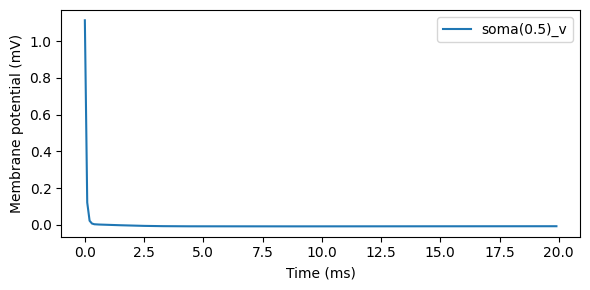

In [10]:
sim_cell = Cell(
    morpho,
    cv_policy=CVPerBranch(cv_per_branch=2),
    solver="staggered",
)

sim_cell.paint(
    BranchSlice(branch_index=[0, 1], prox=0.0, dist=1.0),
    Channel("IL", g_max=0.03 * (u.mS / u.cm ** 2), E=-54.387 * u.mV),
    Channel("Nav1p6_MA24_PC", g_max=120.0 * (u.mS / u.cm ** 2)),
    Channel("IK_HH1952", g_max=36.0 * (u.mS / u.cm ** 2)),
)

sim_cell.place(
    RootLocation(x=0.5),
    CurrentClamp.step(0.1 * u.nA, 5.0 * u.ms, delay=5.0 * u.ms),
)

sim_cell.place(
    at("soma", 0.5),
    StateProbe(),
)

sim_cell.init_state()
# init_state() already called above

dt = 0.1 * u.ms
duration = 10.0 * u.ms

result1 = sim_cell.run(dt=dt, duration=duration)
result2 = sim_cell.run(dt=dt, duration=duration)

times_ms = u.math.concatenate([result1.time, result2.time])
vs_mV = u.math.concatenate([
    result1.traces["soma(0.5)_v"],
    result2.traces["soma(0.5)_v"],
])

print("current_time after two runs:", sim_cell.current_time)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(times_ms, vs_mV, label="soma(0.5)_v")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Membrane potential (mV)")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

You have now seen the main ideas of the cell layer in BrainCell:

- A `Cell` starts in DECLARING — morphology, CV policy, `paint(...)` rules, `place(...)` rules are freely mutable. `init_state()` transitions it to INITIALIZED, where the runtime surface is live.
- Discretization produces a list of `CV`s; the CV policy is the main structural knob.
- `cell.init_state()` lowers the declaration and allocates the runtime (point tree, layouts, integrator state, probes) on the same `Cell`.
- All runtime inspection (`layouts`, `get_point_state(...)`, `get_state(...)`, `point_tree()`, `run(...)`, `current_time`, `sample_probes()`) is available on the `Cell` after `init_state()` (and raises `RuntimeError` in DECLARING).
- Building twice produces two independent runnables, so a single declaration can seed many parallel simulations.

A natural next step is `3.vis.ipynb`, where the structural and runtime views become easier to inspect visually.